# 📗 그래프DB 개념: 관계형 데이터베이스 vs 그래프

지금까지 데이터를 **표(테이블)** 로 다뤄 왔습니다. 표는 정갈하지만, "민준이 산 물건을 산 다른 사람은 또 뭘 샀지?"처럼 **연결을 따라가는 질문**에는 표를 몇 번씩 이어 붙여야 답이 나옵니다. 이번 시간에는 데이터를 **점(노드)과 화살표(관계)** 로 보는 **그래프**를 배웁니다. 연결이 곧 데이터가 되면 그런 질문이 훨씬 자연스러워집니다.

그래프 전용 데이터베이스는 다음 단원에서 설치해 다루고, 오늘은 그 **개념과 사고방식**을 순수 파이썬으로 몸에 익힙니다.

## ⏪ 복습: 지난 시간까지

- **pandas 표 다루기**: `merge` 로 두 표를 공통 열로 이어 붙였습니다. 오늘 이 방식의 한계를 그래프와 견줘 봅니다.
- **파이썬 dict·list**: 그래프를 담는 그릇으로 오늘 dict(노드)와 list(관계)를 씁니다.
- **반복문**: 연결을 따라가는 **순회**를 for 문으로 직접 구현합니다.

**오늘의 목표**

- [ ] 같은 데이터를 **표(RDB)** 와 **그래프** 로 각각 표현하고 차이를 설명한다.
- [ ] 노드·관계·속성·방향으로 **LPG(속성 그래프)** 를 dict/list 로 모델링한다.
- [ ] 노드에 붙은 화살표 수(**차수**)를 세어 그래프를 요약한다.
- [ ] **1홉·2홉 순회**를 반복문으로 구현해 연결을 따라간다.
- [ ] **networkx** 로 그래프를 그림으로 그린다.

---
# 1. 그래프란? 점과 화살표로 데이터 보기

## 왜 필요할까요?
온라인 쇼핑 데이터를 생각해 봅시다. **고객**, **주문**, **상품**이 각각 다른 표에 있습니다. "민준이 주문한 상품의 **이름**"을 알려면 주문 표에서 민준의 상품 id 를 찾고, 다시 상품 표에서 그 id 의 이름을 찾아야 합니다. 표를 **두 번 이어 붙여야(merge)** 답이 나옵니다.

## 비유: 전화번호부 vs 지도
표는 **전화번호부**입니다. 이름으로 번호를 찾을 순 있지만 "이 사람의 친구의 친구"를 알려면 번호부를 계속 되짚어야 합니다. 그래프는 **지도**입니다. 길(관계)이 이미 그려져 있어 손가락으로 따라가기만 하면 됩니다.

<img src="images/교안01/graph_intuition.png" width="820">

> 한 칸 찾기는 표도 빠릅니다. **연결을 따라갈수록** 표는 되짚기가 늘고 그래프는 그대로입니다.

먼저 표(RDB) 방식을 봅니다. 세 표를 만들고, 민준이 산 상품명을 얻으려 두 번 `merge` 합니다.

In [ ]:
import pandas as pd

# 관계형 데이터베이스(RDB) 스타일 - 사실이 세 개의 표에 나뉘어 있다
# 고객 표: 고객 이름은 오직 여기에만 있다
customers = pd.DataFrame([
    {'고객id': 'c1', '이름': '민준'},
    {'고객id': 'c2', '이름': '서연'},
    {'고객id': 'c3', '이름': '지호'},
])
# 상품 표: 상품명도 오직 여기에만 있다
products = pd.DataFrame([
    {'상품id': 'p1', '상품명': '노트북'},
    {'상품id': 'p2', '상품명': '마우스'},
    {'상품id': 'p3', '상품명': '키보드'},
    {'상품id': 'p4', '상품명': '이어폰'},
    {'상품id': 'p5', '상품명': '모니터'},
])
# 주문 표: 고객id 와 상품id 를 한 줄에 같이 들고 있어 두 표를 잇는 다리 역할을 한다
orders = pd.DataFrame([
    {'주문id': 'o1', '고객id': 'c1', '상품id': 'p1'},
    {'주문id': 'o2', '고객id': 'c1', '상품id': 'p2'},
    {'주문id': 'o3', '고객id': 'c2', '상품id': 'p2'},
    {'주문id': 'o4', '고객id': 'c2', '상품id': 'p3'},
    {'주문id': 'o5', '고객id': 'c2', '상품id': 'p4'},
    {'주문id': 'o6', '고객id': 'c3', '상품id': 'p1'},
    {'주문id': 'o7', '고객id': 'c3', '상품id': 'p5'},
])
display(customers)   # 확인: 민준은 c1
display(products)    # 확인: 노트북은 p1, 마우스는 p2
display(orders)      # 확인: c1 의 주문은 o1, o2 이렇게 2줄. 여기엔 이름도 상품명도 없고 id 뿐이다

In [ ]:
# 표 방식: 민준이 주문한 상품명을 얻으려면 두 번 이어 붙인다
step1 = orders.merge(customers, on='고객id')      # 1) 주문 + 고객 -> 주문 줄에 이름이 붙는다
step2 = step1.merge(products, on='상품id')         # 2) 그 결과 + 상품 -> 이제 상품명까지 한 줄에 모인다
# 이어 붙인 표에서 이름이 민준인 줄만 남기고 상품명 열만 꺼낸다
minjun_products = step2[step2['이름'] == '민준']['상품명'].tolist()
print('민준이 산 상품:', minjun_products)   # 출력: ['노트북', '마우스'] - 답 하나에 merge 2회가 들었다

> 연결이 깊어질수록 `merge` 가 하나씩 늘어납니다.

같은 질문을 표와 그래프가 각각 어떻게 푸는지 한 장으로 견줘 봅니다.

<img src="images/교안01/rdb_vs_graph_join.png" width="860">

이번엔 **그래프** 방식입니다. 같은 사실을 노드와 방향 관계로 옮기고, **인접 dict** 로 이웃을 바로 찾습니다.

In [1]:
# 같은 사실을 그래프로 - 노드는 dict, 방향 관계는 list
# 노드: id -> {'label': 레이블, 'props': 속성들}
# 레이블은 그 노드가 무엇인지(고객·상품), props 는 그 노드가 들고 있는 값이다
nodes = {
    'c1': {'label': '고객', 'props': {'이름': '민준'}},
    'c2': {'label': '고객', 'props': {'이름': '서연'}},
    'c3': {'label': '고객', 'props': {'이름': '지호'}},
    'p1': {'label': '상품', 'props': {'상품명': '노트북'}},
    'p2': {'label': '상품', 'props': {'상품명': '마우스'}},
    'p3': {'label': '상품', 'props': {'상품명': '키보드'}},
    'p4': {'label': '상품', 'props': {'상품명': '이어폰'}},
    'p5': {'label': '상품', 'props': {'상품명': '모니터'}},
}
# 관계: (출발 노드, 관계 이름, 도착 노드) - 방향이 있다(고객 -> 상품)
# 표의 orders 7줄이 그대로 관계 7개가 된다. 이어 주는 중간 표가 따로 없다
edges = [
    ('c1', '주문', 'p1'),
    ('c1', '주문', 'p2'),
    ('c2', '주문', 'p2'),
    ('c2', '주문', 'p3'),
    ('c2', '주문', 'p4'),
    ('c3', '주문', 'p1'),
    ('c3', '주문', 'p5'),
]
print('노드', len(nodes), '개 · 관계', len(edges), '개')   # 출력: 노드 8개(고객 3 + 상품 5), 관계 7개

노드 8 개 · 관계 7 개


방금 적은 `nodes` 와 `edges` 를 전부 그리면 이런 모양입니다. 왼쪽이 고객 노드, 오른쪽이 상품 노드이고 **화살표 하나가 주문 한 건**입니다.

<img src="images/교안01/shopping_graph_overview.png" width="820">

In [2]:
# 인접 dict: 각 노드에서 나가는 이웃을 미리 모아 둔다(밖으로 향하는 방향)
adjacency = {}
for src, rel, dst in edges:
    # 한 노드에서 관계가 여러 개 나갈 수 있으므로 값은 하나가 아니라 리스트다
    # setdefault: 그 키가 처음이면 빈 리스트를 깔아 주고, 이미 있으면 있는 리스트를 그대로 쓴다
    adjacency.setdefault(src, []).append(dst)

display(adjacency)   # 확인: 키는 고객 id, 값은 그 고객이 주문한 상품 id 리스트

{'c1': ['p1', 'p2'], 'c2': ['p2', 'p3', 'p4'], 'c3': ['p1', 'p5']}

In [7]:
print('민준(c1) 이 주문한 상품 노드:', adjacency['c3'])   # 출력: ['p1', 'p2'] - 아직 id 뿐이고 이름은 없다

민준(c1) 이 주문한 상품 노드: ['p1', 'p5']


In [8]:
# 그래프 방식: 민준의 이웃(상품 노드)에서 상품명만 꺼낸다(이어 붙이기 없음)
# adjacency 로 이웃 id 를 얻고, 그 id 로 nodes 의 props 에서 상품명을 읽는다(두 번 다 곧장 찾기)
minjun_products_graph = [nodes[pid]['props']['상품명'] for pid in adjacency['c1']]
print('민준이 산 상품:', minjun_products_graph)   # 출력: ['노트북', '마우스'] - 표 방식과 같은 답

민준이 산 상품: ['노트북', '마우스']


> 표를 이어 붙이지 않고 **이웃을 곧장** 읽었습니다. 연결이 데이터 안에 미리 그려져 있기 때문입니다. 위 그림에서 표가 두 번 거쳐 간 길을 그래프는 화살표 하나로 지나갑니다.

### 🖐️ 함께 따라하기: 재현이 본 영화

> 데모는 **온라인 쇼핑**이었습니다. 따라하기는 **영화 시청 그래프**로 같은 기술을 연습합니다.

먼저 아래 셀을 **실행만** 해서 데이터를 불러오고, 어떤 노드와 관계가 있는지 눈으로 훑어보세요. 관객은 영화를 **시청**하고, 영화에는 **감독**이 이어져 있습니다.

In [9]:
# [제공 코드] 따라하기용 영화 시청 그래프(실행만 하세요)
import json
from pathlib import Path

# 노드와 관계를 미리 저장해 둔 json 을 읽는다(구조는 위 데모의 nodes·edges 와 같다)
movie = json.loads(Path('data/followalong_movie_graph.json').read_text(encoding='utf-8'))
movie_nodes = movie['nodes']                       # id -> {'label': .., 'props': {..}}
# json 에는 튜플이 없어 관계가 리스트로 저장된다. 데모와 같은 (출발, 관계, 도착) 튜플로 되돌린다
movie_edges = [tuple(e) for e in movie['edges']]

print('노드', len(movie_nodes), '개 · 관계', len(movie_edges), '개')   # 출력: 노드 11개(관객 3 + 영화 5 + 감독 3) · 관계 14개(시청 8 + 감독 6)

노드 11 개 · 관계 14 개


In [10]:
# [제공 코드] (이어서)
# 노드를 전부 찍어 노드 하나의 생김새(레이블 + 속성 dict)를 눈으로 확인한다
for nid, attr in movie_nodes.items():
    print(nid, attr)                               # 출력: 노드 11줄. 레이블과 props dict 가 함께 나온다

v1 {'label': '관객', 'props': {'이름': '보람'}}
v2 {'label': '관객', 'props': {'이름': '재현'}}
v3 {'label': '관객', 'props': {'이름': '다온'}}
m1 {'label': '영화', 'props': {'제목': '별빛 아래 도시'}}
m2 {'label': '영화', 'props': {'제목': '느린 항해'}}
m3 {'label': '영화', 'props': {'제목': '여름의 문장'}}
m4 {'label': '영화', 'props': {'제목': '붉은 정거장'}}
m5 {'label': '영화', 'props': {'제목': '새벽 두 시의 편지'}}
d1 {'label': '감독', 'props': {'이름': '한도윤'}}
d2 {'label': '감독', 'props': {'이름': '유서진'}}
d3 {'label': '감독', 'props': {'이름': '노가온'}}


In [11]:
# [제공 코드] (이어서)
# 관계도 전부: 세 칸(출발 id, 관계 이름, 도착 id)으로 되어 있다
for e in movie_edges:
    print(e)                                       # 출력: ('v1', '시청', 'm1') 같은 튜플 14줄

('v1', '시청', 'm1')
('v1', '시청', 'm2')
('v1', '시청', 'm3')
('v2', '시청', 'm2')
('v2', '시청', 'm3')
('v2', '시청', 'm4')
('v3', '시청', 'm1')
('v3', '시청', 'm5')
('m1', '감독', 'd1')
('m2', '감독', 'd2')
('m3', '감독', 'd2')
('m3', '감독', 'd3')
('m4', '감독', 'd3')
('m5', '감독', 'd1')


읽어 들인 그래프를 전부 그리면 이렇습니다. 관객에서 영화로, 영화에서 감독으로 화살표가 이어지고 **관계가 시청·감독 두 종류**입니다.

<img src="images/교안01/movie_graph_overview.png" width="880">

In [12]:
# [제공 코드] (이어서)
# 영화마다 감독이 몇 명인지: 한 노드에서 같은 관계가 여러 개 나갈 수 있다
director_count = {}
for src, rel, dst in movie_edges:
    if rel == '감독':                               # 시청 관계는 빼고 감독 관계만 센다
        director_count[src] = director_count.get(src, 0) + 1   # 처음 보는 영화면 0 에서 시작해 1 을 더한다
print('영화별 감독 수:', director_count)   # 출력: 대부분 1, m3 만 2 - 인접 dict 값이 리스트여야 하는 이유

영화별 감독 수: {'m1': 1, 'm2': 1, 'm3': 2, 'm4': 1, 'm5': 1}


위 출력에서 `m3`(여름의 문장)만 감독이 2명입니다. **한 노드에서 같은 관계가 여러 개 나갈 수 있다**는 뜻이고, 그래서 인접 dict 의 값이 하나가 아니라 리스트입니다.

`movie_edges` 의 **시청** 관계로 인접 dict **`watched_adj`**(관객 id -> 그 관객이 본 영화 id 리스트)를 만들고, **관객 `v2`(재현)** 가 본 영화의 **제목** 리스트를 구해 출력하세요. 제목은 `movie_nodes[id]['props']['제목']` 으로 얻습니다.

**확인 기준**: 영화 3편(느린 항해, 여름의 문장, 붉은 정거장)이 출력되면 맞습니다.

In [16]:
# 🖐️ 함께 따라하기 (아래 순서대로 직접 작성해 보세요)
# 1) movie_edges 를 돌며 관계가 '시청' 인 것만 골라 watched_adj 에 모은다
watch_adj = {}
for src, rel, dst in movie_edges:
    if rel == "시청":                               # 시청 관계는 빼고 감독 관계만 센다
         watch_adj.setdefault(src, []).append(dst)
watch_adj
# 2) watched_adj['v2'] 로 재현이 본 영화 id 들을 얻는다
m_ids = watch_adj['v2']
# 3) 각 id 를 movie_nodes[id]['props']['제목'] 으로 바꿔 리스트로 모아 출력한다
m_titles = [movie_nodes[mid]['props']['제목'] for mid in m_ids]
print(m_titles)

['느린 항해', '여름의 문장', '붉은 정거장']


### ✅ 바로 확인 퀴즈

**1.** 표(RDB) 방식에서 "민준이 산 상품명"을 얻으려면 표를 최소 **몇 번** 이어 붙여야 했나요?

<details><summary>정답 보기</summary>

**두 번**입니다(주문+고객, 그다음 +상품). 연결을 하나 더 따라갈 때마다 이어 붙이기가 하나씩 늘어납니다.

</details>

**2.** 그래프 방식이 "연결을 따라가는 질문"에 유리한 이유를 한 문장으로 말해 보세요.

<details><summary>정답 보기</summary>

연결(관계)이 데이터 안에 이미 그려져 있어, 표를 이어 붙이지 않고 **이웃을 곧장 따라가면** 되기 때문입니다.

</details>

---
# 2. LPG 모델: 노드·관계·속성·방향

## 왜 필요할까요?
그래프를 제대로 쓰려면 "무엇을 노드로, 무엇을 관계로, 무엇을 속성으로 둘지"를 정해야 합니다. 그 표준 모델이 **LPG(레이블 붙은 속성 그래프, Labeled Property Graph)** 입니다. 방금 만든 `nodes`·`edges` 가 바로 이 모델입니다.

## 문법: LPG 의 네 부품
| 부품 | 뜻 | 이번 예시 |
|---|---|---|
| 노드(node) | 개체 하나 | 고객 민준, 상품 노트북 |
| 레이블(label) | 노드의 종류 | `고객`, `상품` |
| 관계(relationship) | 노드를 잇는 **방향 있는** 화살표 | 민준 -[주문]-> 노트북 |
| 속성(property) | 노드·관계에 붙는 key-value | 이름=민준, 상품명=노트북 |

**방향이 핵심**입니다. `민준 -[주문]-> 노트북` 은 "민준이 노트북을 주문했다"이지 그 반대가 아닙니다. 우리 `edges` 의 튜플 `(출발, 관계, 도착)` 이 이 방향을 담습니다.

네 부품이 하나의 관계에서 어떻게 맞물리는지 그림으로 먼저 봅니다.

<img src="images/교안01/lpg_anatomy.png" width="760">

노드에서 **레이블별로 골라내기**, **속성으로 필터**하기를 해 봅니다.

In [17]:
# 레이블이 '상품' 인 노드만 골라 상품명을 모은다
# 표였다면 products 표를 따로 읽어야 하지만, 그래프는 한 그릇에서 레이블로 걸러 내면 된다
product_names = [attr['props']['상품명'] for nid, attr in nodes.items() if attr['label'] == '상품']
print('상품 노드:', product_names)   # 출력: 상품 5개 이름. 고객 노드는 걸러져 나오지 않는다

상품 노드: ['노트북', '마우스', '키보드', '이어폰', '모니터']


In [18]:
# 관계를 사람이 읽는 문장으로: 방향을 화살표로 표현
# 출발은 고객이라 '이름', 도착은 상품이라 '상품명' 을 꺼낸다(레이블마다 속성 이름이 다르다)
for src, rel, dst in edges:
    print(f"{nodes[src]['props']['이름']} -[{rel}]-> {nodes[dst]['props']['상품명']}")   # 출력: 관계 7줄

민준 -[주문]-> 노트북
민준 -[주문]-> 마우스
서연 -[주문]-> 마우스
서연 -[주문]-> 키보드
서연 -[주문]-> 이어폰
지호 -[주문]-> 노트북
지호 -[주문]-> 모니터


속성은 노드에만 붙는 것이 아닙니다. 위 표가 말한 대로 **관계(화살표)에도** 붙습니다. 주문 관계에 주문일·수량을 매달아 봅니다.

In [19]:
# 관계에도 속성을 붙일 수 있다: (출발, 관계, 도착) 튜플을 (.., 속성) 네 칸으로 늘린다
# 주문일·수량은 고객의 성질도 상품의 성질도 아니다. 둘을 이은 그 관계에만 매달리는 값이다
edges_with_props = [
    ('c1', '주문', 'p1', {'주문일': '2026-03-02', '수량': 1}),
    ('c1', '주문', 'p2', {'주문일': '2026-03-05', '수량': 2}),
]
for src, rel, dst, props in edges_with_props:
    # 관계 이름 옆에 속성까지 같이 찍어 값이 관계에 붙어 있다는 것을 눈으로 본다(민준의 주문 2줄)
    print(f"{nodes[src]['props']['이름']} -[{rel} {props}]-> {nodes[dst]['props']['상품명']}")

민준 -[주문 {'주문일': '2026-03-02', '수량': 1}]-> 노트북
민준 -[주문 {'주문일': '2026-03-05', '수량': 2}]-> 마우스


> 주문일은 고객의 속성도 상품의 속성도 아니고 **그 둘이 만나는 자리**의 값입니다. 그래서 노드가 아니라 관계에 붙습니다. 레이블은 "이 노드가 무엇인가"를, 속성은 노드·관계 각각의 "세부 값"을 담습니다.

### 🖐️ 함께 따라하기: 영화 그래프의 레이블별 노드 수

> 이어서 **영화 시청 그래프**로 연습합니다.

`movie_nodes` 의 노드를 **레이블별로** 세어 사전 **`movie_label_count`**(키=레이블, 값=개수)에 담고 출력하세요. 각 노드의 레이블은 `attr['label']` 로 읽습니다(관객·영화·감독 세 종류가 있습니다).

**확인 기준**: `{'관객': 3, '영화': 5, '감독': 3}` 이 나오면 맞습니다.

In [28]:
# 🖐️ 함께 따라하기 (아래 순서대로 직접 작성해 보세요)
# 1) 빈 dict movie_label_count 를 만든다
movie_label_count = {}

# 2) movie_nodes.values() 를 돌며 attr['label'] 을 키로 개수를 1씩 더한다
for attr in movie_nodes.values() :
    print(attr)
    movie_label_count[attr['label']] = movie_label_count.get(attr['label'], 0) + 1

# 3) 출력한다
print(movie_label_count)

{'label': '관객', 'props': {'이름': '보람'}}
{'label': '관객', 'props': {'이름': '재현'}}
{'label': '관객', 'props': {'이름': '다온'}}
{'label': '영화', 'props': {'제목': '별빛 아래 도시'}}
{'label': '영화', 'props': {'제목': '느린 항해'}}
{'label': '영화', 'props': {'제목': '여름의 문장'}}
{'label': '영화', 'props': {'제목': '붉은 정거장'}}
{'label': '영화', 'props': {'제목': '새벽 두 시의 편지'}}
{'label': '감독', 'props': {'이름': '한도윤'}}
{'label': '감독', 'props': {'이름': '유서진'}}
{'label': '감독', 'props': {'이름': '노가온'}}
{'관객': 3, '영화': 5, '감독': 3}


### ✅ 바로 확인 퀴즈

**1.** `('c1', '주문', 'p1')` 이 담고 있는 사실을 방향까지 넣어 한 문장으로 풀어 쓰면?

<details><summary>정답 보기</summary>

"고객 민준(c1)이 상품 노트북(p1)을 **주문했다**" 입니다. 화살표는 c1 에서 p1 로 향하며, 반대 방향이 아닙니다.

</details>

**2.** "이름", "상품명" 같은 값은 LPG 의 네 부품 중 무엇에 해당하나요?

<details><summary>정답 보기</summary>

**속성(property)** 입니다. 노드가 무엇인지는 레이블이, 그 세부 값은 속성이 담습니다.

</details>

---
# 3. 차수: 그래프를 한 줄로 요약하기

## 왜 필요할까요?
노드가 수백 개가 되면 그림으로도 한눈에 안 들어옵니다. 그럴 때 가장 먼저 보는 것이 **노드마다 화살표가 몇 개 붙어 있나**입니다. 누가 활발한 고객인지, 어떤 상품이 인기인지가 이 숫자 하나로 드러납니다.

## 문법: 나가는 차수와 들어오는 차수
노드 하나에 붙은 화살표 수를 **차수(degree)** 라고 합니다. 방향이 있으니 두 가지로 나뉩니다.

| 이름 | 뜻 | 이 그래프에서 |
|---|---|---|
| 나가는 차수(out-degree) | 그 노드에서 **나가는** 화살표 수 | 고객이 주문한 상품 수 |
| 들어오는 차수(in-degree) | 그 노드로 **들어오는** 화살표 수 | 그 상품을 주문한 고객 수 |

노드 하나에 화살표가 어느 쪽으로 몇 개 붙어 있는지를 그림으로 먼저 봅니다.

<img src="images/교안01/degree_in_out.png" width="860">

엣지를 한 번만 훑으면 둘 다 셀 수 있습니다.

In [29]:
# 차수: 엣지 하나가 출발 노드의 out 을 1, 도착 노드의 in 을 1 올린다
out_degree = {}
in_degree = {}
for src, rel, dst in edges:
    # 관계 하나를 양쪽에서 한 번씩 센다. 그래서 두 dict 의 값 합계는 둘 다 관계 수와 같다
    out_degree[src] = out_degree.get(src, 0) + 1
    in_degree[dst] = in_degree.get(dst, 0) + 1

# 이렇게 세면 한 번도 안 걸린 노드는 키 자체가 생기지 않는다. 여기선 다섯 상품이 다 팔려 키가 5개다
print('고객별 주문 수(나가는 차수):', out_degree)    # 출력: c2 가 3 으로 가장 많이 주문했다
print('상품별 주문 수(들어오는 차수):', in_degree)   # 출력: p1·p2 가 2, 나머지 셋은 1

고객별 주문 수(나가는 차수): {'c1': 2, 'c2': 3, 'c3': 2}
상품별 주문 수(들어오는 차수): {'p1': 2, 'p2': 2, 'p3': 1, 'p4': 1, 'p5': 1}


> 들어오는 차수가 큰 상품이 여러 고객에게 팔린 상품입니다. 관계가 여러 종류 섞인 그래프라면 **세기 전에 관계 종류를 먼저 걸러야** 원하는 차수가 나옵니다.

> 출력을 보면 `out_degree` 에는 고객 세 명만, `in_degree` 에는 상품 다섯 개만 들어 있습니다. **모든 노드가 두 dict 에 다 있는 것은 아닙니다.** 그래서 차수를 읽을 때는 `in_degree.get('c1', 0)` 처럼 **없을 때의 값**을 함께 정해 두는 편이 안전합니다.

### 🖐️ 함께 따라하기: 영화별 시청자 수 세기

> 이어서 **영화 시청 그래프**로 연습합니다.

`movie_edges` 의 **시청** 관계만 세어 사전 **`movie_view_count`**(영화 id -> 그 영화를 본 관객 수)를 만들고, 제목과 함께 한 줄씩 출력하세요. 시청 관계의 **들어오는 차수**입니다. 이 그래프에는 `감독` 관계도 섞여 있으니 세기 전에 걸러야 합니다.

**확인 기준**: 영화 5편이 나오고 별빛 아래 도시·느린 항해·여름의 문장이 **2**, 붉은 정거장·새벽 두 시의 편지가 **1** 이면 맞습니다.

In [24]:
# 🖐️ 함께 따라하기 (아래 순서대로 직접 작성해 보세요)
# 1) 빈 dict movie_view_count 를 만든다
movie_view_count = {}
# 2) movie_edges 를 돌며 관계가 '시청' 인 것만 골라 도착(영화) 쪽 개수를 1씩 더한다
for src, rel, dst in movie_edges :
    if rel == '시청' :
        movie_view_count[dst] = movie_view_count.get(dst, 0) + 1
print(movie_view_count)

# 3) 영화 제목과 개수를 한 줄씩 출력한다


{'m1': 2, 'm2': 2, 'm3': 2, 'm4': 1, 'm5': 1}


In [26]:
# 🖐️ 함께 따라하기 (아래 순서대로 직접 작성해 보세요)
# 1) 빈 dict movie_view_count 를 만든다
movie_view_count = {}

# 2) movie_edges 를 돌며 관계가 '시청' 인 것만 골라 도착(영화) 쪽 개수를 1씩 더한다
for src, rel, dst in movie_edges :
    if rel == '시청' :
        movie_view_count[dst] = movie_view_count.get(dst, 0) + 1
print(movie_view_count) # 영화별 in_degree

# 3) 영화 제목과 개수를 한 줄씩 출력한다
for mid, cnt in movie_view_count.items() :
    print(f"영화제목:{movie_nodes[mid]['props']['제목']}", cnt)

{'m1': 2, 'm2': 2, 'm3': 2, 'm4': 1, 'm5': 1}
영화제목:별빛 아래 도시 2
영화제목:느린 항해 2
영화제목:여름의 문장 2
영화제목:붉은 정거장 1
영화제목:새벽 두 시의 편지 1


### ✅ 바로 확인 퀴즈

**1.** 관계가 `시청`·`감독` 두 종류인 그래프에서 "그 영화를 본 관객 수"를 세려면 무엇을 먼저 해야 하나요?

<details><summary>정답 보기</summary>

**관계 종류로 먼저 거릅니다**(`rel == '시청'` 인 엣지만). 걸러내지 않으면 영화에서 감독으로 나가는 화살표까지 섞여 관객 수가 아닌 값이 나옵니다.

</details>

**2.** 감독 노드의 **나가는 차수**가 0 이라는 것은 무슨 뜻인가요?

<details><summary>정답 보기</summary>

그 노드에서 밖으로 나가는 화살표가 하나도 없다는 뜻입니다(막다른 길). 이 그래프에서 감독은 도착점이기만 합니다. 인접 dict 를 만들어도 감독 id 는 키로 들어가지 않으므로 대괄호로 바로 읽으면 `KeyError` 가 납니다. `.get(감독id, [])` 처럼 **없을 때의 값**을 정해 읽어야 빈 리스트가 돌아옵니다.

</details>

---
# 4. 그래프 순회: 1홉·2홉 따라가기

## 왜 필요할까요?
그래프의 힘은 **연결을 따라가는 것**에 있습니다. 한 칸 가는 걸 **1홉(1-hop)**, 두 칸 가는 걸 **2홉(2-hop)** 이라 부릅니다. "민준이 산 상품"은 1홉, "민준이 산 상품을 산 다른 고객이 산 또 다른 상품"(= 함께 살 만한 추천)은 2홉입니다.

## 문법: 1홉씩 넓혀 가기
1홉은 인접 dict 를 한 번 읽는 것, 2홉은 그 결과에서 **다시 한 번** 이웃을 읽는 것입니다. 이렇게 **1홉씩 넓혀 가며** 따라갑니다. 3홉·4홉도 같은 방식으로 이어 갑니다.

먼저 방향을 거슬러 "이 상품을 산 고객"도 찾을 수 있게 **역방향 인접 dict** 도 만듭니다.

In [25]:
# 역방향 인접 dict: 상품 -> 그 상품을 산 고객들 (관계를 거슬러 올라간다)
reverse_adj = {}
for src, rel, dst in edges:
    # 앞의 adjacency 와 키·값을 반대로 담기만 하면 된다. 관계 목록 자체는 그대로다
    reverse_adj.setdefault(dst, []).append(src)

display(reverse_adj)   # 확인: 키는 상품 id, 값은 그 상품을 산 고객 id 리스트

{'p1': ['c1', 'c3'],
 'p2': ['c1', 'c2'],
 'p3': ['c2'],
 'p4': ['c2'],
 'p5': ['c3']}

In [30]:
print('노트북(p1) 을 산 고객:', reverse_adj['p1'])   # 출력: ['c1', 'c3'] - 민준과 지호

노트북(p1) 을 산 고객: ['c1', 'c3']


In [31]:
# 1홉: 어떤 노드의 직접 이웃(나가는 방향)
def one_hop(start):
    """start 에서 1홉에 닿는 이웃 id 리스트를 돌려준다."""
    # 이웃이 하나도 없는 노드(막다른 길)는 인접 dict 에 키가 없다. 없으면 빈 리스트로 받는다
    return adjacency.get(start, [])

# 2홉 추천: 내가 산 상품(1홉)을 산 다른 고객이 산, 내가 아직 안 산 상품
def recommend(customer):
    """customer 에게 추천할 상품 id 집합을 돌려준다."""
    my_products = set(one_hop(customer))          # 1홉: 내가 산 상품
    result = set()                                 # 여러 경로로 같은 상품이 걸려도 한 번만 담기게 set
    for pid in my_products:                        # 각 상품마다
        for other in reverse_adj.get(pid, []):     # 그 상품을 산 고객들(관계를 거꾸로 1홉)
            if other == customer:
                continue                           # 나 자신은 건너뛴다(아래 my_products 조건이 어차피 걸러 주지만 뜻을 분명히 한다)
            for pid2 in one_hop(other):            # 그 고객이 산 상품들(2홉)
                if pid2 not in my_products:         # 내가 아직 안 산 것만
                    result.add(pid2)
    return result

rec_ids = recommend('c1')
rec_names = sorted(nodes[pid]['props']['상품명'] for pid in rec_ids)   # id 는 사람이 못 읽으니 이름으로 바꾼다
print('민준에게 추천:', rec_names)   # 출력: ['모니터', '이어폰', '키보드'] - 취향이 겹친 서연·지호를 거쳐 나왔다

민준에게 추천: ['모니터', '이어폰', '키보드']


> 표 방식이었다면 `merge` 를 여러 번 겹쳐야 했을 "함께 살 만한 상품"이, 그래프에서는 **이웃 → 이웃**을 두 번 따라가는 것으로 끝납니다. 이게 2홉 순회의 힘입니다.

방금 실행한 순회가 어느 길을 지나갔는지 단계별로 펼쳐 보면 이렇습니다.

<img src="images/교안01/two_hop_traversal.png" width="860">

### 🖐️ 함께 따라하기: 재현에게 영화 추천

> 이어서 **영화 시청 그래프**로 같은 2홉 순회를 해 봅니다.

**역방향 인접 dict `watched_by`**(영화 id -> 그 영화를 본 관객 id 리스트)를 만들고, 앞서 만든 `watched_adj` 와 함께 써서 **재현(`v2`)** 에게 추천할 영화 **제목**을 정렬해 출력하세요. 추천은 "재현이 본 영화를 본 다른 관객이 본, 재현이 아직 안 본 영화"입니다.

**확인 기준**: 추천 영화는 **1편**(별빛 아래 도시)입니다. 재현이 본 세 편 중 `붉은 정거장`은 재현 말고는 본 사람이 없어 2홉이 뻗지 않습니다.

In [39]:
# 🖐️ 함께 따라하기 (아래 순서대로 직접 작성해 보세요)
# 1) 시청 관계로 역방향 인접 dict watched_by(영화 -> 관객들)를 만든다
watched_by = {}
for src, rel, dst in movie_edges :
    if rel == '시청' :
        watched_by.setdefault(dst, []).append(src)
print(watched_by)

# 2) 재현이 본 영화 집합 mine 을 구한다
mine = set(watch_adj['v2'])
print(mine)

# 3) mine 의 각 영화를 본 다른 관객이 본 영화를 모으되, mine 에 있는 것은 뺀다
m_recommend = set()

#내가 본 영화 ID 순회
for mid in mine : # 재현(v2)가 본 영화 1홉
    # 내가 본 영화를 본 사람들 id가져와서 순회
    for other in watched_by.get(mid, []) :
        if other == 'v2' : #다른 사람이 'v2'(내가) 아닌 경우만 처리
            continue

        # 다른 사람이 본 영화 id 목록 순회
        for mid2 in watch_adj.get(other, []) : # 다른 사람이 본 영화 2홉
            if mid2 not in mine : #다른 사람이 본 영화 중 내가 보지 않은 것만 
                m_recommend.add(mid2)

# 4) 남은 id 를 제목으로 바꿔 sorted 로 정렬해 출력한다        
print(sorted([movie_nodes[m_id]['props']['제목'] for m_id in m_recommend]))

{'m1': ['v1', 'v3'], 'm2': ['v1', 'v2'], 'm3': ['v1', 'v2'], 'm4': ['v2'], 'm5': ['v3']}
{'m3', 'm4', 'm2'}
['별빛 아래 도시']


### ✅ 바로 확인 퀴즈

**1.** "민준이 산 상품"은 몇 홉이고, "민준이 산 상품을 산 다른 고객이 산 상품"은 몇 홉인가요?

<details><summary>정답 보기</summary>

앞은 **1홉**, 뒤는 **2홉**입니다. 이웃을 한 번 읽으면 1홉, 그 이웃에서 다시 한 번 읽으면 2홉입니다.

</details>

**2.** "이 상품을 산 고객"을 찾으려면 왜 **역방향** 인접 dict 가 필요한가요?

<details><summary>정답 보기</summary>

관계 `주문` 은 고객→상품 방향이라, 상품에서 고객으로 거슬러 가려면 방향을 뒤집은 인접 dict 가 필요합니다.

</details>

---
# 5. networkx 로 그래프 그리기

## 왜 필요할까요?
그래프는 **눈으로 볼 때** 구조가 확 들어옵니다. 파이썬의 **networkx** 는 그래프를 담고 그리는 라이브러리입니다. 지난 단원에서는 동시 출현 네트워크를 그려 주는 함수를 받아 쓰기만 했는데, 오늘은 그 안을 직접 만들어 봅니다.

## 문법: 방향 그래프 만들고 그리기
- `nx.DiGraph()` : 방향 그래프 그릇을 만든다(Di = directed).
- `G.add_node(id, **속성)` / `G.add_edge(출발, 도착)` : 노드·관계를 넣는다.
- `nx.draw(G, pos, ...)` : 그림으로 그린다. 한글 라벨은 폰트를 맞춰 준다.

실행하면 이런 그림이 나옵니다.

<img src="images/교안01/shopping_graph_catalog.png" width="620">

그리기 전에 아래 폰트 셀을 먼저 실행하세요(운영체제에 맞는 한글 폰트를 잡아 줍니다).

In [40]:
import platform
import matplotlib.pyplot as plt

# 그림에 한글 라벨이 들어가므로 폰트를 먼저 잡는다. 안 잡으면 글자가 네모로 나온다
# 한글 폰트: 실행 중인 OS 에 맞춰 자동 설정
if platform.system() == 'Windows':
    KOREAN_FONT = 'Malgun Gothic'
    FONT_PATH = 'C:/Windows/Fonts/malgun.ttf'
elif platform.system() == 'Darwin':          # macOS
    KOREAN_FONT = 'AppleGothic'
    FONT_PATH = '/System/Library/Fonts/Supplemental/AppleGothic.ttf'
else:                                        # Linux (Colab 등)
    KOREAN_FONT = 'NanumGothic'
    FONT_PATH = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

plt.rcParams['font.family'] = KOREAN_FONT    # 이후 모든 그림에 이 폰트가 적용된다
plt.rcParams['axes.unicode_minus'] = False   # 마이너스(−) 부호 깨짐 방지

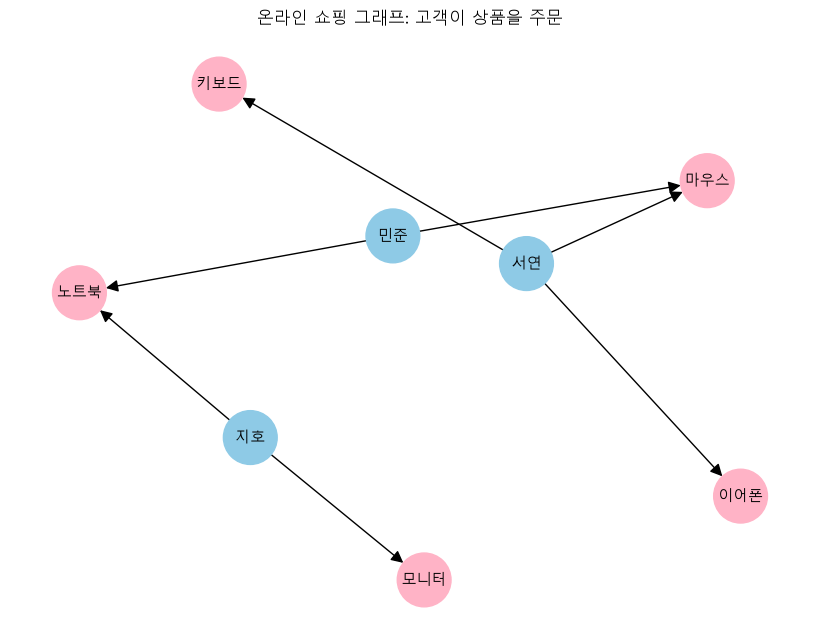

In [41]:
import networkx as nx

# 방향 그래프 그릇에 노드·관계를 담는다
G = nx.DiGraph()                             # DiGraph 는 방향 있는 그래프. Graph 로 만들면 화살표가 사라진다
for nid, attr in nodes.items():
    # 고객은 '이름', 상품은 '상품명' 에 화면에 보일 글자가 들어 있다(레이블마다 속성 이름이 다르다)
    label = attr['props'].get('이름') or attr['props'].get('상품명')
    # add_node 의 키워드는 내가 붙이는 노드 속성이다. label 은 화면에 쓸 글자,
    # kind 는 노드 종류(고객·상품)로 아래에서 색을 고를 때 쓴다
    G.add_node(nid, label=label, kind=attr['label'])
for src, rel, dst in edges:
    G.add_edge(src, dst)                     # 그림에는 관계 이름을 쓰지 않으므로 출발·도착만 넘긴다

# 색: 고객은 하늘색, 상품은 연분홍
colors = ['#8ecae6' if G.nodes[n]['kind'] == '고객' else '#ffb3c6' for n in G.nodes]
labels = {n: G.nodes[n]['label'] for n in G.nodes}   # 화면에 id 대신 이름이 보이게 하는 짝

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)          # 배치를 고정(seed)해 매번 같은 그림
nx.draw(G, pos, labels=labels, node_color=colors, node_size=1500,
        font_family=KOREAN_FONT, font_size=11, arrows=True, arrowsize=18)
plt.title('온라인 쇼핑 그래프: 고객이 상품을 주문')
plt.show()                                   # 확인: 하늘색 3개에서 분홍색 5개로 화살표 7개가 뻗는다

> 화살표가 **고객 → 상품** 으로 향합니다. 한 상품에 화살표가 여러 개 모이면 여러 고객이 산 인기 상품이라는 뜻입니다(예: 마우스). 그림만 봐도 2홉 추천의 길이 보입니다.

### 🖐️ 함께 따라하기: 영화 시청 그래프 그리기

> 이어서 **영화 시청 그래프**를 직접 그려 봅니다.

`movie_nodes`·`movie_edges` 로 방향 그래프 **`G_movie`** 를 만들어 그리세요.

- 노드 라벨: 관객·감독은 `props['이름']`, 영화는 `props['제목']`
- 색: 관객 `'#8ecae6'`(하늘색) · 영화 `'#ffb3c6'`(연분홍) · 감독 `'#ffe6a7'`(연노랑)
- `node_size=1800`, 배치는 `spring_layout` 에 `seed=42`, 제목은 `'영화 시청 그래프'`
- 새 그림이므로 `plt.figure()` 로 새 도화지를 먼저 여는 것을 잊지 마세요.

**확인 기준**: 노드 11개가 세 가지 색(하늘색 관객 3 · 연분홍 영화 5 · 연노랑 감독 3)으로 그려지고, 화살표가 관객 → 영화 → 감독 방향으로 이어지면 맞습니다.

In [ ]:
# 🖐️ 함께 따라하기 (아래 순서대로 직접 작성해 보세요)
# 1) nx.DiGraph() 를 만들고 movie_nodes 로 노드를(라벨·레이블 함께) 넣는다
# 2) movie_edges 의 (출발, 관계, 도착) 중 출발·도착으로 관계를 넣는다
# 3) 레이블별 색 dict 를 만들어 노드 색 리스트를 만든다
# 4) plt.figure 로 새 도화지를 열고 spring_layout(seed=42) 배치로 nx.draw 한다
# 5) plt.title('영화 시청 그래프') 를 넣고 plt.show()

['#8ecae6', '#8ecae6', '#8ecae6', '#ffb3c6', '#ffb3c6', '#ffb3c6', '#ffb3c6', '#ffb3c6', '#ffe6a7', '#ffe6a7', '#ffe6a7']
{'v1': '보람', 'v2': '재현', 'v3': '다온', 'm1': '별빛 아래 도시', 'm2': '느린 항해', 'm3': '여름의 문장', 'm4': '붉은 정거장', 'm5': '새벽 두 시의 편지', 'd1': '한도윤', 'd2': '유서진', 'd3': '노가온'}


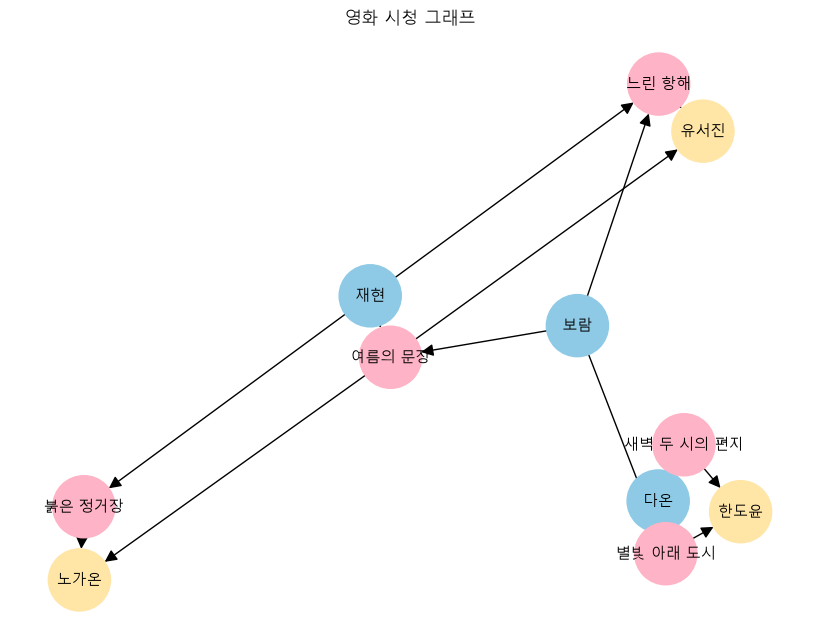

In [46]:
# 🖐️ 함께 따라하기 (아래 순서대로 직접 작성해 보세요)
# 1) nx.DiGraph() 를 만들고 movie_nodes 로 노드를(라벨·레이블 함께) 넣는다
# 2) movie_edges 의 (출발, 관계, 도착) 중 출발·도착으로 관계를 넣는다
# 3) 레이블별 색 dict 를 만들어 노드 색 리스트를 만든다
# 4) plt.figure 로 새 도화지를 열고 spring_layout(seed=42) 배치로 nx.draw 한다
# 5) plt.title('영화 시청 그래프') 를 넣고 plt.show()

G_movie = nx.DiGraph()
for nid, attr in movie_nodes.items() :
    label = attr['props'].get('이름') or attr['props'].get('제목')

    #label : 노드의 속성값 (사람이름, 영화제목), kind의 label값 노드의 타입 (영화, 인물)
    G_movie.add_node(nid, label=label, kind=attr['label']) 

for src, rel, dst in movie_edges :
    G_movie.add_edge(src, dst)


palette = {'관객': '#8ecae6', '영화': '#ffb3c6', '감독': '#ffe6a7'}
movie_colors = [palette[G_movie.nodes[n]['kind']] for n in G_movie.nodes]
print(movie_colors)
movie_labels = {n: G_movie.nodes[n]['label'] for n in G_movie.nodes}
print(movie_labels)

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G_movie, seed=1800)          # 배치를 고정(seed)해 매번 같은 그림
nx.draw(G_movie, pos, labels=movie_labels, node_color=movie_colors, node_size=2000,
        font_family=KOREAN_FONT, font_size=11, arrows=True, arrowsize=18)
plt.title('영화 시청 그래프')
plt.show()   

### ✅ 바로 확인 퀴즈

**1.** 방향 그래프 그릇을 만드는 함수는 무엇인가요?

<details><summary>정답 보기</summary>

**`nx.DiGraph()`** 입니다(방향이 없으면 `nx.Graph()`). 우리 주문 관계는 방향이 있으므로 `DiGraph` 를 씁니다.

</details>

**2.** `spring_layout` 에 `seed=42` 를 준 이유는?

<details><summary>정답 보기</summary>

배치를 **고정**해 그릴 때마다 노드 위치가 같아지게 하기 위해서입니다(재현 가능한 그림).

</details>

---
## 🚀 응용 클론코딩: 공동 구매 상품 찾기

두 고객 id 를 받아 **둘 다 산 상품명**(공통 이웃)을 정렬된 리스트로 돌려주는 `common_products(c_a, c_b)` 를 완성하세요. 각자의 1홉 상품 집합을 구해 **교집합**을 내면 됩니다. `common_products('c1', 'c2')` 로 호출해 출력하세요.

**확인 기준**: `['마우스']` 한 개가 나옵니다.

In [47]:
# 🚀 응용 (아래 순서대로 직접 작성해 보세요)
# 1) common_products(c_a, c_b) 를 정의한다
# 2) 각 고객의 one_hop 결과를 set 으로 만들어 교집합(&)을 구한다
# 3) 교집합의 상품 id 를 상품명으로 바꿔 sorted 로 정렬해 반환한다
# 4) common_products('c1', 'c2') 로 호출해 출력한다

def common_products(c_a, c_b) :
    """
     두 고객 c_a, c_b가 함께산 상품 이름을 정렬해 반환
    """

    both = set(one_hop(c_a)) & set(one_hop(c_b))
    return sorted(nodes[pid]['props']['상품명'] for pid in both)

print(common_products('c1', 'c2'))

['마우스']


---
## 이번 강의 정리

| 개념 | 핵심 |
|---|---|
| RDB vs 그래프 | 표는 연결마다 이어 붙이기(merge), 그래프는 이웃을 곧장 따라가기 |
| LPG | 노드·레이블·관계(방향)·속성. 속성은 노드에도 관계에도 붙는다 |
| 차수 | 노드에 붙은 화살표 수. 나가는 차수·들어오는 차수로 그래프를 요약 |
| 순회 | 1홉=이웃 한 번, 2홉=이웃의 이웃. 1홉씩 넓혀 간다 |
| 역방향 인접 | 관계를 거슬러 "이 상품을 산 고객" 찾기 |
| networkx | `DiGraph`·`add_node`·`add_edge`·`draw` 로 그래프 시각화 |

**표와 그래프, 언제 무엇을 쓰나**

| 질문의 모양 | 유리한 쪽 |
|---|---|
| 연결을 따라가는 질문(추천·경로·N홉) | 그래프 |
| 정형 집계·정합성·트랜잭션(월별 매출 합계 같은) | 표(RDB) |

- 같은 사실도 **표**로 보면 이어 붙이기가, **그래프**로 보면 순회가 됩니다.
- 그래프가 늘 낫다는 뜻은 아닙니다. 이미 평평한 표를 단순히 집계할 때는 `merge` 나 판다스가 더 빠르고 간단합니다. **연결을 따라가는 질문이 많을 때** 그래프가 값을 합니다.

## ⏭️ 예고: 다음 시간

오늘은 데이터를 그래프로 **모델링**했습니다. 다음 시간에는 그래프에 **의미 규칙**을 입힌 **지식 그래프**와 **온톨로지**를 배웁니다. 어떤 노드와 관계만 허용할지 정하고, 실존 인물·국가·직업 데이터를 **RDF 트리플**로 탐색합니다.

수고하셨습니다!